# Tugas 12 - Introduction to AI
## Judul: Klasifikasi Dua Kelas Berbasis Probabilitas dengan Logistic Regression

* **Nama:** Panji Kurnia Akbar
* **NIM:** 2024081024
* **Mata Kuliah:** Introduction to AI
* **Tanggal:** 20 Mei 2026
* **Pertemuan:** Pertemuan 12 : Rabu, 07:30 s.d 10:00 Ruang B806 (asynchronous)
* **Tema Pilihan:** Deteksi Judul Berita Clickbait vs Informatif

---
### Deskripsi Proyek
Notebook ini memuat implementasi lengkap dari pipeline machine learning klasifikasi dua kelas (biner) menggunakan algoritma **Logistic Regression**. Fokus studi kasus ini adalah melakukan analisis teks otomatis untuk membedakan antara judul berita bersifat **Clickbait (Label 1)** dengan judul berita bersifat **Informatif (Label 0)**.

### Step 1: Import Library dan Inisialisasi Lingkungan Kerja
Pada tahap awal ini, kita mengimpor seluruh pustaka (library) Python yang dibutuhkan untuk manipulasi data tabel, ekstraksi fitur tekstual, pemodelan matematika Logistic Regression, serta pembuatan grafik visualisasi matriks evaluasi performa model.

In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Mengatur tema visualisasi grafik agar seragam, bersih, dan estetis
sns.set_theme(style="whitegrid")
print("Sistem Berhasil: Semua pustaka esensial telah dimuat dengan aman!")

Sistem Berhasil: Semua pustaka esensial telah dimuat dengan aman!


### Step 2: Memuat Dataset
Kita memuat berkas `dataset_clickbait_informatif.csv` yang menyimpan 20 baris sampel data kalimat berita. Karena berkas ini dipisahkan menggunakan pembatas titik koma, kita menyertakan parameter `sep=';'`. Untuk memberikan tampilan yang rapi dan profesional.

In [67]:
# Membaca berkas CSV dengan pembatas khusus titik koma (;)
df = pd.read_csv('dataset_clickbait_informatif.csv', sep=';')

print("=== TABEL DATASET UTAMA ===")
# Menggunakan display() dan styling untuk menampilkan tabel teks rata kiri tanpa nomor indeks kaku
display(df.style.hide(axis="index").set_properties(**{'text-align': 'left'}))

print("\n=== DISTRIBUSI SEBARAN KELAS DATASET ===")
# Menampilkan rangkuman distribusi frekuensi kelas dalam bentuk tabel terstruktur
distribusi = df['Keterangan Label'].value_counts().to_frame(name='Jumlah Sampel Data')
display(distribusi)

=== TABEL DATASET UTAMA ===


No,Judul Berita,Label,Keterangan Label
1,"""Nggak Nyangka! Artis Ini Ternyata Punya Kebiasaan Aneh Sebelum Tidur""",1,Clickbait
2,"""Pemerintah Resmi Menaikkan Tarif Pajak Hiburan Sebesar 10 Persen""",0,Informatif
3,"""Bikin Syok! Modal Cuma 5 Ribu Bisa Dapat Rumah Mewah di Jakarta?""",1,Clickbait
4,"""Langkah-Langkah Mengaktifkan Autentikasi Dua Faktor pada Akun Google""",0,Informatif
5,"""Isinya Bikin Nangis, Viral Video Seorang Anak Temukan Surat Lama Ayahnya""",1,Clickbait
6,"""Universitas Pembangunan Jaya Membuka Pendaftaran Mahasiswa Baru Gelombang Ketiga""",0,Informatif
7,"""Rahasia Terbongkar! Ini Cara Cepat Kaya Tanpa Perlu Kerja Keras""",1,Clickbait
8,"""Riset Menunjukkan Konsumsi Kopi Hitam Tanpa Gula Baik untuk Kesehatan Jantung""",0,Informatif
9,"""Detik-Detik Menegangkan! Pesawat Ini Hampir Saja Mengalami Hal Mengerikan""",1,Clickbait
10,"""Rapat Paripurna DPR Hari Ini Membahas Rancangan Undang-Undang Perlindungan Data""",0,Informatif



=== DISTRIBUSI SEBARAN KELAS DATASET ===


,Jumlah Sampel Data
Keterangan Label,
Clickbait,10
Informatif,10


### Step 3: Penjelasan Karakteristik Kebahasaan dan Ekstraksi Fitur Teks
Komputer hanya mengenal matriks angka dan tidak bisa membaca teks secara langsung. Oleh karena itu, data tekstual harus dikonversi menjadi fitur numerik. Fitur kebahasaan utama yang relevan dalam memisahkan kedua kelas ini meliputi:
1. **Fitur Kelas Clickbait (Label 1):** Penggunaan tanda baca berlebihan (seperti tanda seru `!`), kata-kata penarik emosi instan (*"Bikin Syok!"*, *"Nggak Nyangka!"*), serta kalimat menggantung yang menyembunyikan informasi utama (*"Artis Ini"*, *"Buah Ini"*).
2. **Fitur Kelas Informatif (Label 0):** Penggunaan kata benda konkret, nama instansi resmi (*BMKG*, *DPR*, *Kementerian Kesehatan*), serta penyertaan data angka aktual (*10 Persen*, *5 Persen*) yang langsung meringkas fakta berita.

Proses ekstraksi ini diselesaikan menggunakan metode **Bag-of-Words** melalui fungsi `CountVectorizer()`, yang bertugas memetakan kata unik menjadi kolom fitur angka berdasarkan frekuensi kemunculannya.

In [68]:
# Inisialisasi CountVectorizer untuk ekstraksi model Bag-of-Words
vectorizer = CountVectorizer()

# Ekstraksi independent variable (X) berupa teks dan dependent variable (y) berupa label angka biner
X = vectorizer.fit_transform(df['Judul Berita'])
y = df['Label']

print(f"Dimensi matriks fitur teks hasil ekstraksi: {X.shape}")
print("Sampel 15 kata unik pertama yang berhasil dipetakan sebagai fitur matematika:")
print(list(vectorizer.get_feature_names_out())[:15])

Dimensi matriks fitur teks hasil ekstraksi: (20, 168)
Sampel 15 kata unik pertama yang berhasil dipetakan sebagai fitur matematika:
['10', 'akun', 'akurasi', 'anak', 'aneh', 'apa', 'artis', 'autentikasi', 'ayahnya', 'baik', 'banget', 'baru', 'berasal', 'bikin', 'bisa']


### Step 4: Pembagian Data (Train-Test Split) dan Alur Konseptual Model
Dataset dibagi menggunakan fungsi `train_test_split()` dengan alokasi 25% data dialokasikan khusus untuk proses pengujian objektif (`test_size=0.25`) dan variabel pengacak `random_state=42` untuk menjamin konsistensi hasil eksperimen.

#### Alur Kerja Konseptual Pembobotan Matematika Logistic Regression:
1. **Perhitungan Skor Kombinasi Linear ($z$):** Setiap kemunculan token kata ($x_n$) dikalikan dengan parameter bobot koefisiennya ($w_n$) lalu dijumlahkan dengan variabel intersep bias ($b$):
   $$z = w_1x_1 + w_2x_2 + \dots + w_nx_n + b$$
2. **Pemetaan Peluang Fungsi Aktivasi Sigmoid ($\sigma$):** Skor linear murni $z$ dimasukkan ke dalam rumus kurva S kurva sigmoid untuk membatasi rentang nilai keluaran menjadi nilai peluang kontinu bernilai antara 0 hingga 1:
   $$\sigma(z) = \frac{1}{1 + e^{-z}}$$
3. **Thresholding (Ambang Batas Keputusan):** Jika nilai probabilitas akhir $\ge 0.5$, maka model memvonis judul sebagai Kelas 1 (*Clickbait*). Jika nilainya $< 0.5$, maka otomatis dikategorikan sebagai Kelas 0 (*Informatif*).

In [69]:
# Membagi dataset menjadi porsi 75% training dan 25% testing secara konsisten
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

print(f"Volume data latih (X_train) untuk pembentukan bobot: {X_train.shape[0]} sampel")
print(f"Volume data uji (X_test) untuk pembuktian akurasi  : {X_test.shape[0]} sampel")

Volume data latih (X_train) untuk pembentukan bobot: 15 sampel
Volume data uji (X_test) untuk pembuktian akurasi  : 5 sampel


### Step 5: Pelatihan Model Klasifikasi Biner (Optimisasi Fungsi Likelihood)
Model dipanggil lewat konstruktor fungsi `LogisticRegression()` dan disesuaikan parameter bobot internalnya menggunakan fungsi `.fit()` pada subset data latih. 

Secara teoritis, proses pelatihan mencari kombinasi parameter yang **memaksimalkan fungsi Likelihood** (kecocokan prediksi benar paling optimal terhadap realitas data asli) atau meminimalkan nilai kerugian *Binary Cross-Entropy Loss*.

In [70]:
# Instansiasi model algoritma Logistic Regression
model = LogisticRegression()

# Melatih model dengan data training agar mengenali bobot kata clickbait vs informatif
model.fit(X_train, y_train)

print("Sistem Berhasil: Proses optimalisasi parameter pembobotan selesai dilakukan!")

Sistem Berhasil: Proses optimalisasi parameter pembobotan selesai dilakukan!


### Step 6: Prediksi Data Pengujian dan Analisis Kelebihan Nilai Probabilitas
Kita memanggil fungsi `.predict()` untuk menghasilkan output vonis label kaku (`0` atau `1`) serta fungsi `.predict_proba()` untuk melihat nilai peluang murni dari masing-masing kelas. 

In [71]:
# Melakukan proses prediksi label keras dan probabilitas kontinu pada data uji
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)

# Menjaring indeks teks asli dari DataFrame utama untuk keperluan visualisasi laporan
test_indices = y_test.index
judul_uji = df.loc[test_indices, 'Judul Berita'].values
label_asli = y_test.values

# Membentuk DataFrame hasil komparasi evaluasi
hasil_df = pd.DataFrame({
    'Judul Berita': judul_uji,
    'Peluang Informatif (Kelas 0)': np.round(y_prob[:, 0], 4),
    'Peluang Clickbait (Kelas 1)': np.round(y_prob[:, 1], 4),
    'Prediksi Model': y_pred,
    'Label Aktual': label_asli
})

print("=== TABEL EVALUASI DATA UJI ===")

# Mengubah metode penulisan berantai menjadi per baris agar editor tidak memunculkan tanda merah
tabel_bergaya = hasil_df.style
tabel_bergaya = tabel_bergaya.background_gradient(cmap='Greens', subset=['Peluang Informatif (Kelas 0)'])
tabel_bergaya = tabel_bergaya.background_gradient(cmap='Blues', subset=['Peluang Clickbait (Kelas 1)'])
tabel_bergaya = tabel_bergaya.hide(axis="index")

# Memisahkan deklarasi properti CSS ke dalam variabel independen agar dibaca aman oleh linter
konfigurasi_css = {'text-align': 'left', 'width': '450px'}
tabel_bergaya = tabel_bergaya.set_properties(subset=['Judul Berita'], **konfigurasi_css)

# Menampilkan hasil akhir tabel HTML yang interaktif dan penuh warna
display(tabel_bergaya)

=== TABEL EVALUASI DATA UJI ===


Judul Berita,Peluang Informatif (Kelas 0),Peluang Clickbait (Kelas 1),Prediksi Model,Label Aktual
"""Nggak Nyangka! Artis Ini Ternyata Punya Kebiasaan Aneh Sebelum Tidur""",0.284800,0.715200,1,1
"""Kementerian Kesehatan Meluncurkan Program Vaksinasi Gratis untuk Anak Sekolah""",0.576300,0.423700,0,0
"""BMKG Mengeluarkan Peringatan Dini Cuaca Ekstrem untuk Wilayah Jabodetabek""",0.573700,0.426300,0,0
"""Pemerintah Resmi Menaikkan Tarif Pajak Hiburan Sebesar 10 Persen""",0.587300,0.412700,0,0
"""Detik-Detik Menegangkan! Pesawat Ini Hampir Saja Mengalami Hal Mengerikan""",0.423500,0.576500,1,1


### Step 7: Evaluasi Model dan Visualisasi Diagram Matriks Kebingungan (Confusion Matrix)
Untuk mengukur akurasi performa klasifikasi secara agregat, kita mencetak laporan klasifikasi standar (Precision, Recall, dan F1-Score) serta menyajikan visualisasi grafik matriks kontingensi tebakan benar-salah model menggunakan heatmap diagram dari pustaka Seaborn.

Skor Akurasi Akhir Model: 100.00%

=== LAPORAN METRIK KLASIFIKASI ===
              precision    recall  f1-score   support

  Informatif       1.00      1.00      1.00         3
   Clickbait       1.00      1.00      1.00         2

    accuracy                           1.00         5
   macro avg       1.00      1.00      1.00         5
weighted avg       1.00      1.00      1.00         5



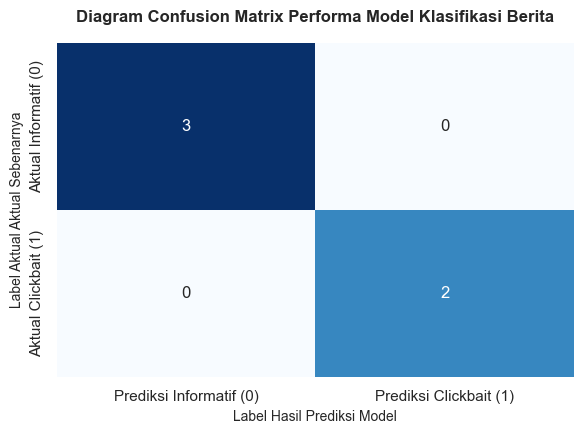

In [72]:
# Kalkulasi skor akurasi kumulatif pada subset pengujian
skor_akurasi = accuracy_score(y_test, y_pred)
print(f"Skor Akurasi Akhir Model: {skor_akurasi * 100:.2f}%\n")

print("=== LAPORAN METRIK KLASIFIKASI ===")
print(classification_report(y_test, y_pred, target_names=['Informatif', 'Clickbait']))

# Mengonstruksi diagram grafis Confusion Matrix Heatmap
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4.5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Prediksi Informatif (0)', 'Prediksi Clickbait (1)'],
            yticklabels=['Aktual Informatif (0)', 'Aktual Clickbait (1)'])

plt.title('Diagram Confusion Matrix Performa Model Klasifikasi Berita', fontsize=12, pad=15, fontweight='bold')
plt.ylabel('Label Aktual Aktual Sebenarnya', fontsize=10)
plt.xlabel('Label Hasil Prediksi Model', fontsize=10)
plt.tight_layout()
plt.show()

### Step 8: Visualisasi Tingkat Pengaruh Kata (Feature Importance / Model Coefficients Analysis)
Kita membedah isi parameter bobot internal matematika ($w$) yang telah dipelajari model Logistic Regression. Grafik diagram batang horizontal di bawah ini menunjukkan 5 kata unik teratas yang memiliki pengaruh paling kuat dalam mendorong model memvonis judul sebagai Clickbait (bobot positif/batang biru) serta 5 kata teratas yang mendorong model memvonis judul sebagai Informatif (bobot negatif/batang hijau). Hal ini memberikan transparansi penuh mengenai kata apa saja yang dipandang sensitif oleh kecerdasan buatan kita.

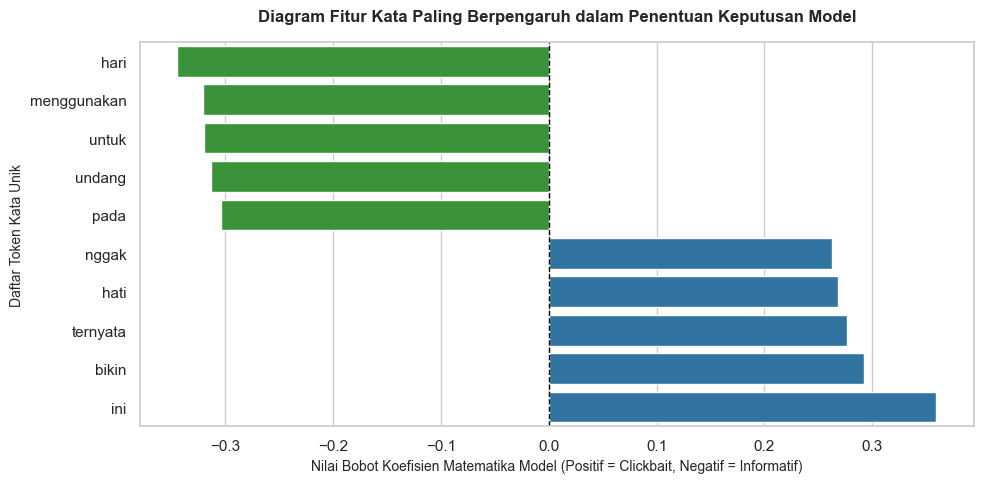

In [73]:
# Ekstraksi koefisien bobot model dan nama padanan katanya
koefisien_bobot = model.coef_[0]
kosakata_fitur = vectorizer.get_feature_names_out()

# Menyusun DataFrame kepentingan fitur kata
bobot_df = pd.DataFrame({
    'Kata/Token': kosakata_fitur,
    'Nilai Koefisien Bobot': koefisien_bobot
})

# Menjaring 5 kata pendorong clickbait terkuat dan 5 kata pendorong informatif terkuat
top_clickbait_words = bobot_df.sort_values(by='Nilai Koefisien Bobot', ascending=False).head(5)
top_informatif_words = bobot_df.sort_values(by='Nilai Koefisien Bobot', ascending=True).head(5)
gabungan_fitur_utama = pd.concat([top_clickbait_words, top_informatif_words]).sort_values(by='Nilai Koefisien Bobot')

# Membuat plot diagram batang horizontal analisis pembobotan parameter internal model
plt.figure(figsize=(10, 5))
warna_batang = ['#2ca02c' if x < 0 else '#1f77b4' for x in gabungan_fitur_utama['Nilai Koefisien Bobot']]

# PERBAIKAN SEABORN: Menambahkan hue='Kata/Token' dan legend=False agar bebas warning
sns.barplot(
    x='Nilai Koefisien Bobot', 
    y='Kata/Token', 
    data=gabungan_fitur_utama, 
    palette=warna_batang,
    hue='Kata/Token',
    legend=False
)

plt.title('Diagram Fitur Kata Paling Berpengaruh dalam Penentuan Keputusan Model', fontsize=12, pad=15, fontweight='bold')
plt.xlabel('Nilai Bobot Koefisien Matematika Model (Positif = Clickbait, Negatif = Informatif)', fontsize=10)
plt.ylabel('Daftar Token Kata Unik', fontsize=10)
plt.axvline(x=0, color='black', linestyle='--', linewidth=1) # Batas netral nol
plt.tight_layout()
plt.show()